In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('C://Users//Dell_USA//Downloads//house_data_set.csv')
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [4]:
# Set a general style for the plots
sns.set(style="whitegrid")

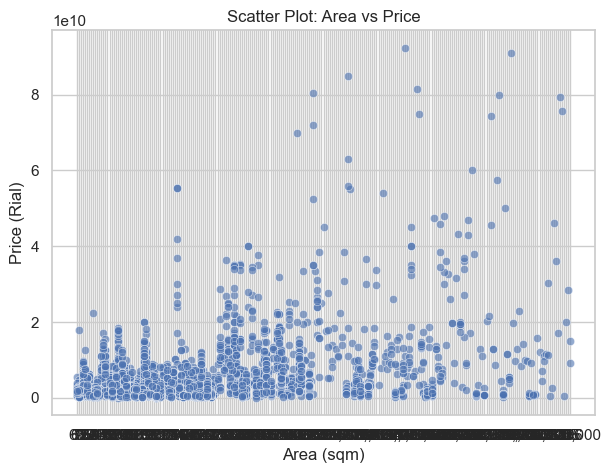

In [5]:
# 1. Scatter Plot: Area vs Price
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Area", y="Price", alpha=0.6)
plt.title("Scatter Plot: Area vs Price")
plt.xlabel("Area (sqm)")
plt.ylabel("Price (Rial)")
plt.show()

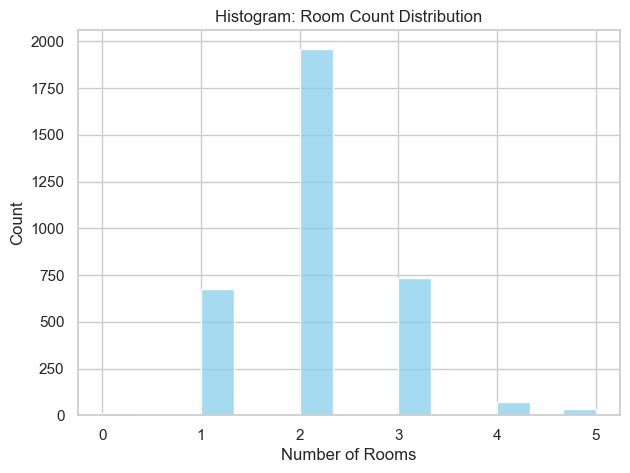

In [6]:
# 2. Histogram: Distribution of Room counts
plt.figure(figsize=(7, 5))
sns.histplot(df["Room"], bins=15, kde=False, color="skyblue")
plt.title("Histogram: Room Count Distribution")
plt.xlabel("Number of Rooms")
plt.ylabel("Count")
plt.show()

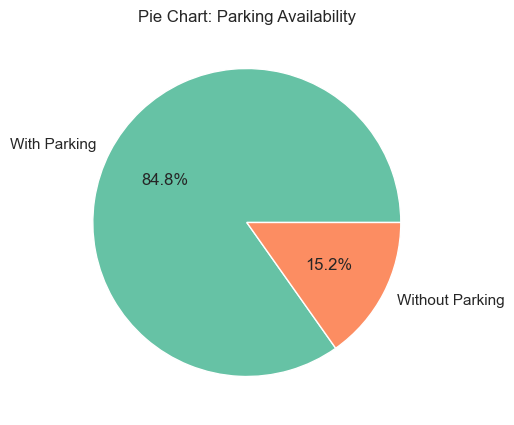

In [7]:
# 3. Pie Chart: Parking availability
plt.figure(figsize=(7, 5))
parking_counts = df["Parking"].value_counts()
plt.pie(parking_counts, labels=["With Parking", "Without Parking"], autopct='%1.1f%%', colors=["#66c2a5", "#fc8d62"])
plt.title("Pie Chart: Parking Availability")
plt.show()

C:\Users\Dell_USA\AppData\Local\Temp\ipykernel_9180\2048588069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_areas.values, y=top_areas.index, palette="viridis")


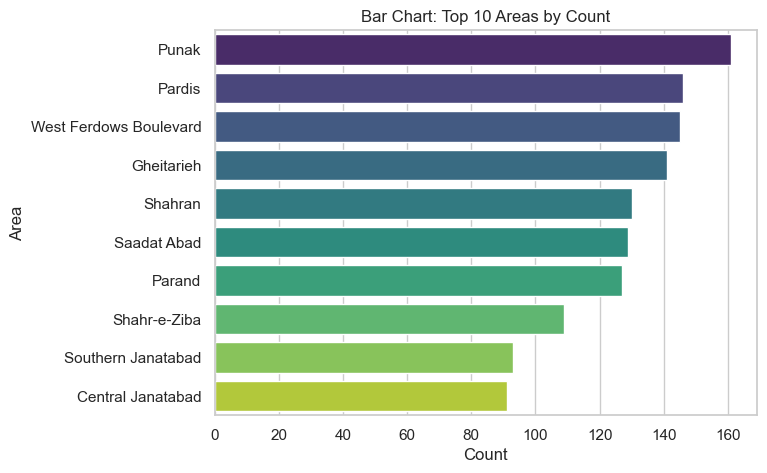

In [8]:
# 5. Bar Chart: Top 10 Areas by Count
plt.figure(figsize=(7, 5))
top_areas = df["Address"].value_counts().head(10)
sns.barplot(x=top_areas.values, y=top_areas.index, palette="viridis")
plt.title("Bar Chart: Top 10 Areas by Count")
plt.xlabel("Count")
plt.ylabel("Area")
plt.show()

In [9]:
# data general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


In [13]:
df.describe()

,Room,Price,Price(USD)
count,3479.000000,3.479000e+03,3.479000e+03
mean,2.079908,5.359023e+09,1.786341e+05
std,0.758275,8.099935e+09,2.699978e+05
min,0.000000,3.600000e+06,1.200000e+02
25%,2.000000,1.418250e+09,4.727500e+04
50%,2.000000,2.900000e+09,9.666667e+04
75%,2.000000,6.000000e+09,2.000000e+05
max,5.000000,9.240000e+10,3.080000e+06


In [14]:
# finding null info in data
df.isnull().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [15]:
# finding duplicate info in data
df.duplicated().sum()

208

In [16]:
# Removing duplicates
df_cleaned = df.drop_duplicates()

In [18]:
df_cleaned.duplicated().sum()

0

In [20]:
# Removing null
df_cleaned = df_cleaned.dropna()

In [22]:
# Handling missing values in 'Address' column without deleting them
#df_cleaned["Address"].fillna("Unknown")

In [23]:
df_cleaned = df.sort_values(by="Area")
df_cleaned.head(7)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
807,"1,000",2,True,True,False,Damavand,7.000000e+09,233333.33
709,"16,160,000,000",3,True,True,True,Pasdaran,1.616000e+10,538666.67
2802,"2,550,000,000",2,True,True,True,Central Janatabad,2.550000e+09,85000.00
570,"3,310,000,000",2,True,True,True,Ostad Moein,3.310000e+09,110333.33
2171,"3,600",2,False,False,False,Shahryar,9.720000e+09,324000.00
1604,"8,400,000,000",2,True,True,True,Gheitarieh,8.700000e+09,290000.00
934,100,2,True,True,True,West Ferdows Boulevard,3.450000e+09,115000.00


In [24]:
# delete outlier data
df_cleaned=df_cleaned.drop([709,2802,570,1604,807,2171])
df_cleaned = df_cleaned.sort_values(by="Area")
df_cleaned.head(7)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
934,100,2,True,True,True,West Ferdows Boulevard,3.450000e+09,115000.00
774,100,2,True,True,True,Qasr-od-Dasht,3.250000e+09,108333.33
2384,100,2,False,False,False,Kahrizak,1.200000e+09,40000.00
2717,100,2,True,True,True,Narmak,3.800000e+09,126666.67
787,100,2,True,True,True,Farmanieh,6.200000e+09,206666.67
1949,100,2,True,True,True,Ekhtiarieh,6.500000e+09,216666.67
797,100,2,True,True,True,Pardis,5.000000e+08,16666.67


In [25]:
df_cleaned['Area'] = df_cleaned['Area'].str.replace(',','')
df_cleaned['Area'] = df_cleaned['Area'].astype('int64')

In [26]:
df_cleaned = df_cleaned.drop(df_cleaned[200<df_cleaned.Area].index)
df_cleaned.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
934,100,2,True,True,True,West Ferdows Boulevard,3.450000e+09,115000.00
774,100,2,True,True,True,Qasr-od-Dasht,3.250000e+09,108333.33
2384,100,2,False,False,False,Kahrizak,1.200000e+09,40000.00
2717,100,2,True,True,True,Narmak,3.800000e+09,126666.67
787,100,2,True,True,True,Farmanieh,6.200000e+09,206666.67


C:\Users\Dell_USA\AppData\Local\Temp\ipykernel_9180\3305282393.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned['Price(USD)'])


<Axes: xlabel='Price(USD)', ylabel='Density'>

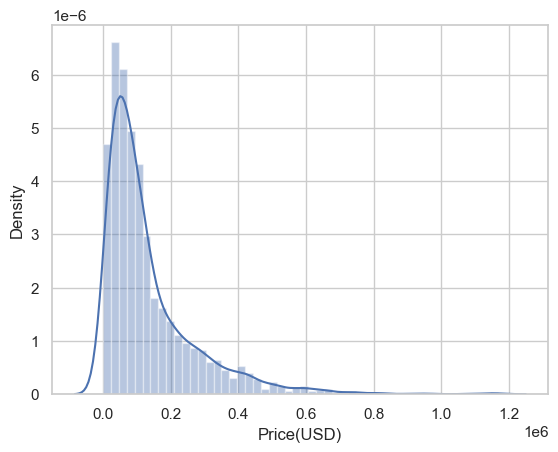

In [27]:
sns.distplot(df_cleaned['Price(USD)'])

In [28]:
#converting Yes and No to 0 and 1
#converting Address to numbers

from sklearn.preprocessing import LabelEncoder

df_cleaned['Address']=LabelEncoder().fit_transform(df_cleaned['Address'])
df_cleaned['Parking']=LabelEncoder().fit_transform(df_cleaned['Parking'])
df_cleaned['Elevator']=LabelEncoder().fit_transform(df_cleaned['Elevator'])

In [29]:
df_cleaned=df_cleaned.rename({"Price(USD)":"PriceUSD"}, axis='columns')

In [30]:
df_cleaned.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,PriceUSD
934,100,2,1,True,1,178,3.450000e+09,115000.00
774,100,2,1,True,1,121,3.250000e+09,108333.33
2384,100,2,0,False,0,73,1.200000e+09,40000.00
2717,100,2,1,True,1,96,3.800000e+09,126666.67
787,100,2,1,True,1,48,6.200000e+09,206666.67


In [31]:
df_cleaned.shape

(3282, 8)

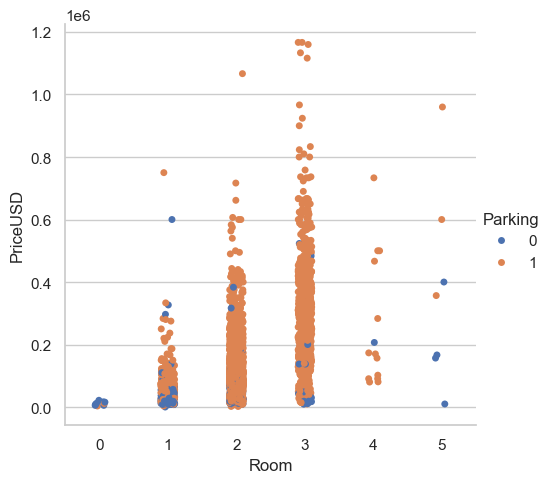

In [33]:
sns.catplot( x="Room",y="PriceUSD",hue="Parking",data=df_cleaned)

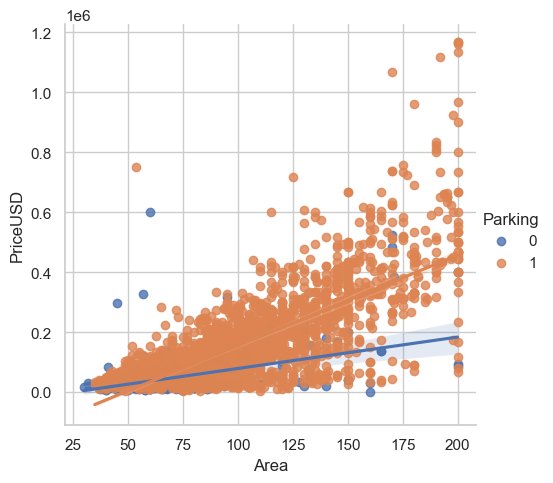

In [34]:
#sns.catplot( x="Area",y="PriceUSD",hue="Parking",data=df)
sns.lmplot(x="Area", y="PriceUSD",hue="Parking", data=df_cleaned)

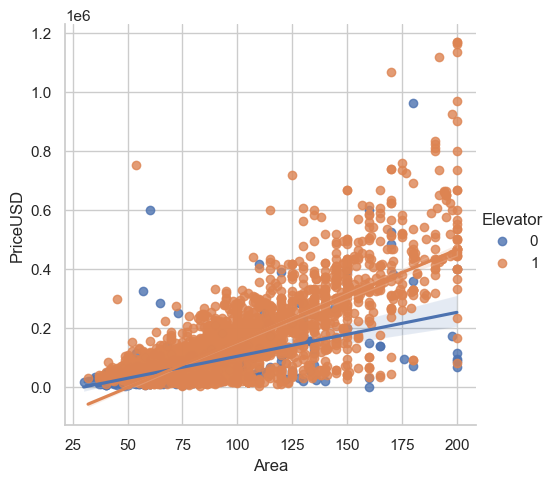

In [35]:
#sns.catplot( x="Area",y="PriceUSD",hue="Elevator",data=df)
sns.lmplot(x="Area", y="PriceUSD",hue="Elevator", data=df_cleaned)

In [36]:
from sklearn.preprocessing import MinMaxScaler

# Selecting numeric columns for normalization
numeric_columns = ["Area", "Price","Room"]
data_numeric = df_cleaned[numeric_columns]

# Step 1: Applying MinMaxScaler
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_numeric)

# Step 2: Creating a DataFrame for normalized data
data_normalized_df = pd.DataFrame(data_normalized, columns=numeric_columns)

# Step 3: Adding the normalized data back to the original dataset (optional)
data_final = pd.concat([df_cleaned.drop(columns=numeric_columns), data_normalized_df], axis=1)

# Saving the normalized dataset to a new CSV file
data_final.to_csv("normalized_data.csv", index=False)

# Printing the normalized data (optional)
print("Normalized Data:")
print(data_normalized_df.head())

Normalized Data:
       Area     Price  Room
0  0.411765  0.098479   0.4
1  0.411765  0.092764   0.4
2  0.411765  0.034186   0.4
3  0.411765  0.108480   0.4
4  0.411765  0.177058   0.4


In [37]:
data_final.head()

,Parking,Warehouse,Elevator,Address,PriceUSD,Area,Price,Room
934,1.0,True,1.0,178.0,115000.00,0.688235,0.238493,0.6
774,1.0,True,1.0,121.0,108333.33,0.617647,0.424226,0.4
2384,0.0,False,0.0,73.0,40000.00,0.264706,0.022185,0.4
2717,1.0,True,1.0,96.0,126666.67,0.323529,0.014756,0.4
787,1.0,True,1.0,48.0,206666.67,0.617647,0.499949,0.4


<Axes: >

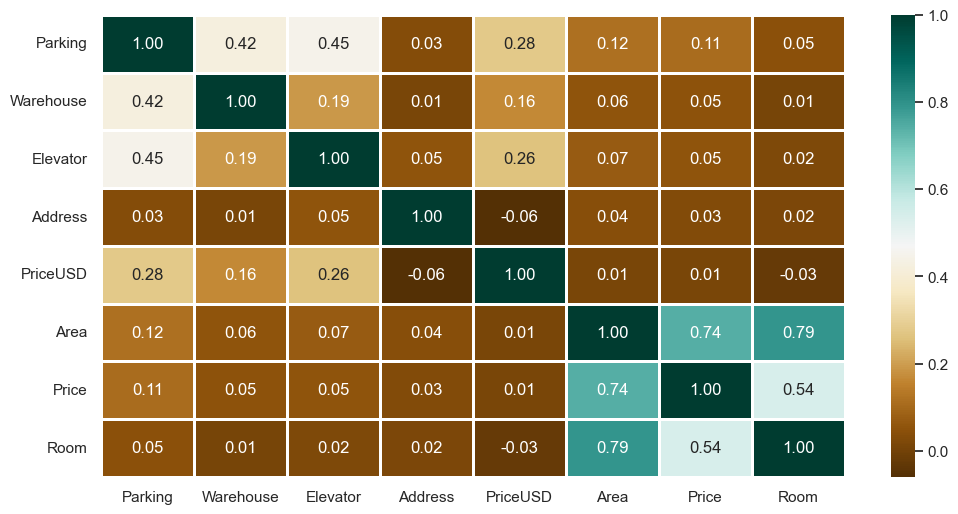

In [39]:
plt.figure(figsize=(12, 6))
sns.heatmap(data_final.corr(),
            cmap = 'BrBG',
            fmt = '.2f',
            linewidths = 2,
            annot = True)

In [40]:
data_final.isnull().sum()

Parking      196
Warehouse    196
Elevator     196
Address      196
PriceUSD     196
Area         196
Price        196
Room         196
dtype: int64

In [41]:
data_final = data_final.dropna()

In [43]:
data_final.duplicated().sum()

2

In [44]:
df_cleaned = df.drop_duplicates()

In [45]:
#Kmean clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [46]:
#load dataset
df = data_final

In [63]:
features = ["Area", "Price"]
df = df[features]

In [64]:
scaler = StandardScaler()

In [65]:
df_scaled = scaler.fit_transform(df)

In [66]:
kmeans = KMeans(n_clusters=5, random_state=42,n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

In [67]:
df.head()

,Area,Price,Cluster
934,0.688235,0.238493,1
774,0.617647,0.424226,1
2384,0.264706,0.022185,3
2717,0.323529,0.014756,0
787,0.617647,0.499949,1


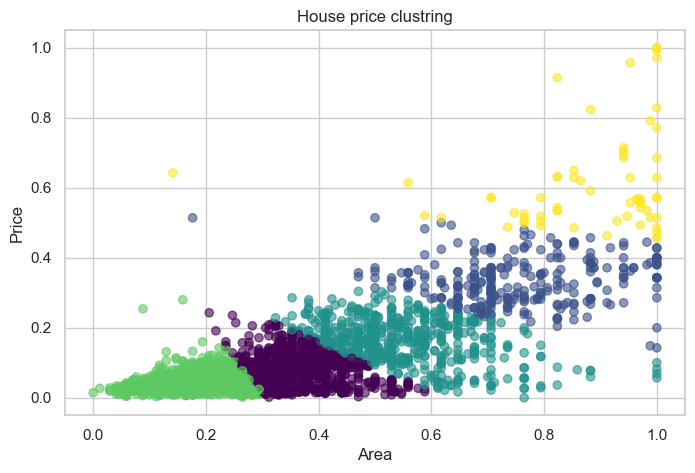

In [69]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Area'],df['Price'],c=df['Cluster'],cmap='viridis',alpha=0.6)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('House price clustring')
plt.show()


In [70]:
df.to_csv("clustered_data.csv", index=False)

In [71]:
#Hierarchical Clustering
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

In [74]:
#load dataset
data = data_final

In [75]:
columns_to_use = ["Address", "Price"]
data_selected = data[columns_to_use]

In [76]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_selected)

In [77]:
# Reducing the data size (random sampling)
sampled_data = data_scaled[:30] if len(data_scaled) > 30 else data_scaled

In [78]:
linkage_matrix = linkage(sampled_data, method='single')

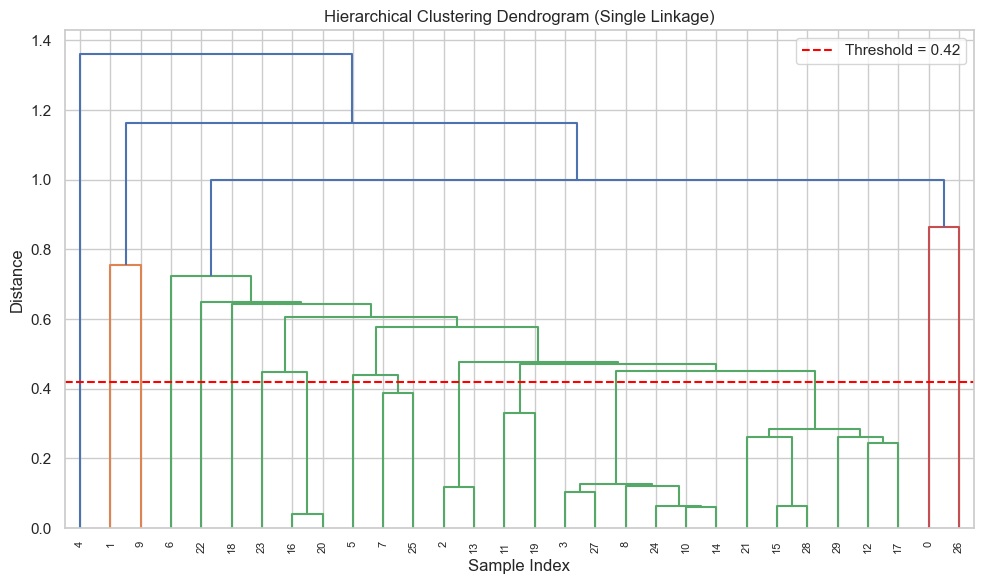

In [79]:
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=8)
distance_threshold = 0.42 
plt.axhline(y=distance_threshold, color='red', linestyle='--', label=f'Threshold = {distance_threshold}')
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
clusters = fcluster(linkage_matrix, t=distance_threshold, criterion='distance')

In [81]:
sampled_data_df = pd.DataFrame(sampled_data, columns=["Address_scaled", "Price_scaled"])
sampled_data_df["Cluster"] = clusters

In [82]:
print(f"Number of clusters: {len(set(clusters))}")

Number of clusters: 16
